/Users/itaiboss/Desktop/4th_year/ELEC413
['2025_03_20_14_49_02_LIV_Isweep_MACOM_C10 in mW.mat', '2025_03_20_14_51_59_LIV_Isweep_MACOM_C10 in mW.mat', '2025_03_20_14_53_18_LIV_Isweep_MACOM_C10 in mW (1).mat']


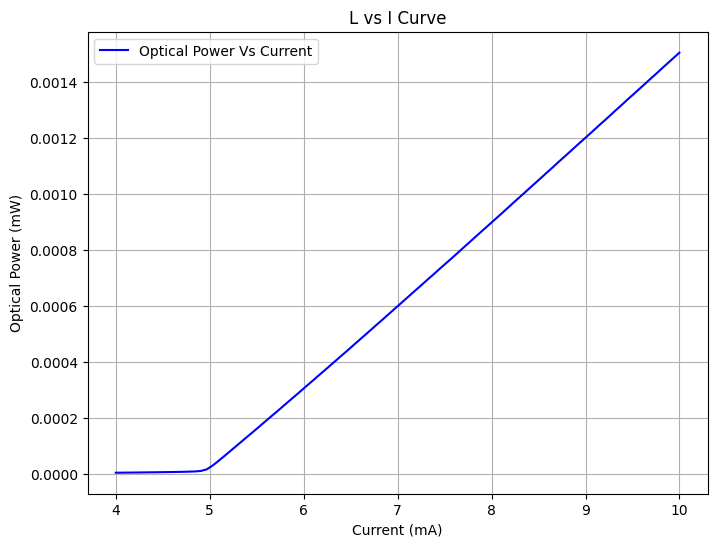

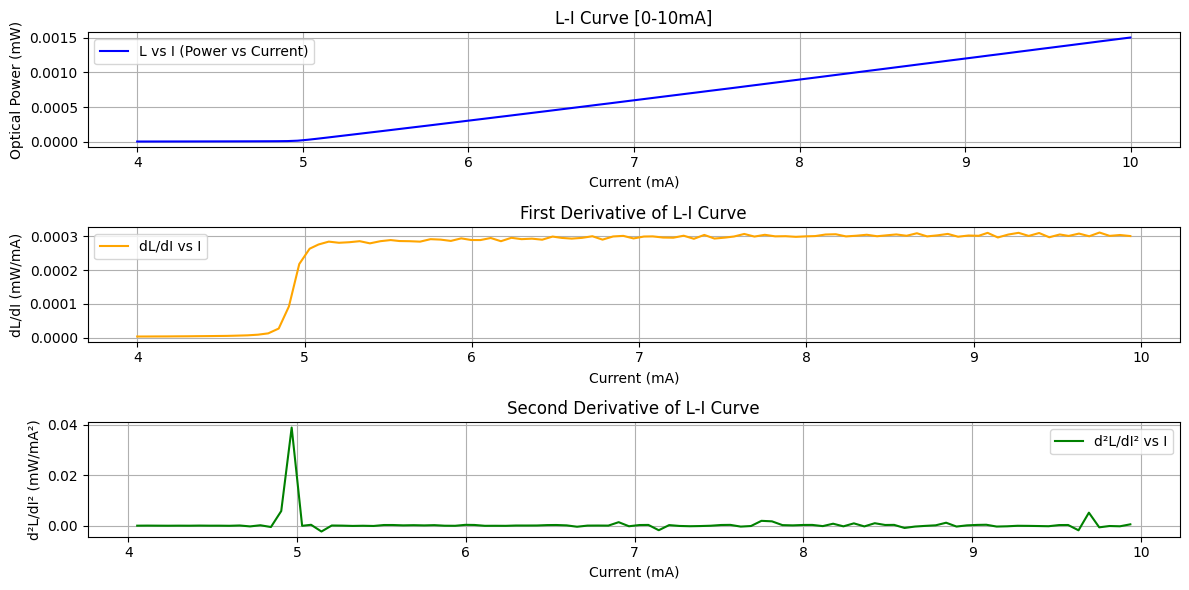

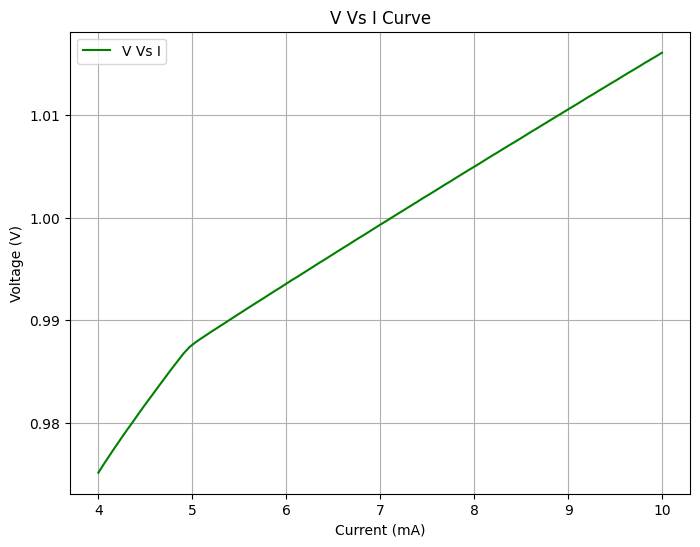

Threshold Resistance (Ith): 0.01181669394435341 Ohm
Threshold Resistance (2*Ith): 0.005397082658021333 Ohm


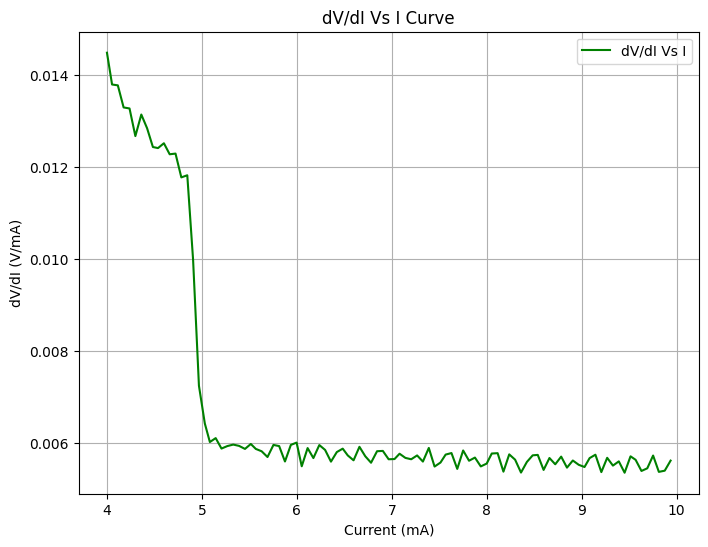

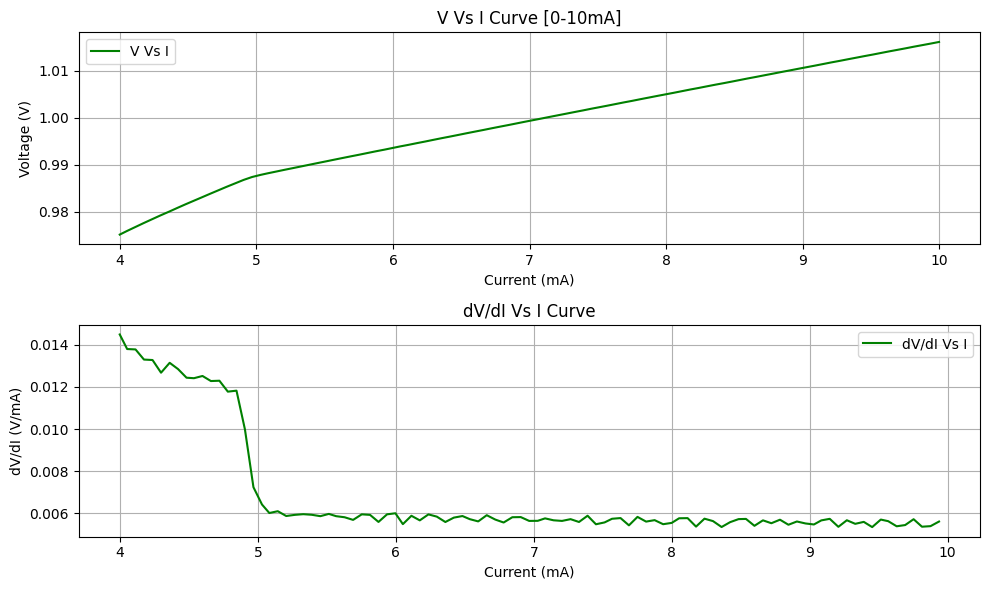

Threshold current from d_IdVdI: 4.9679 A


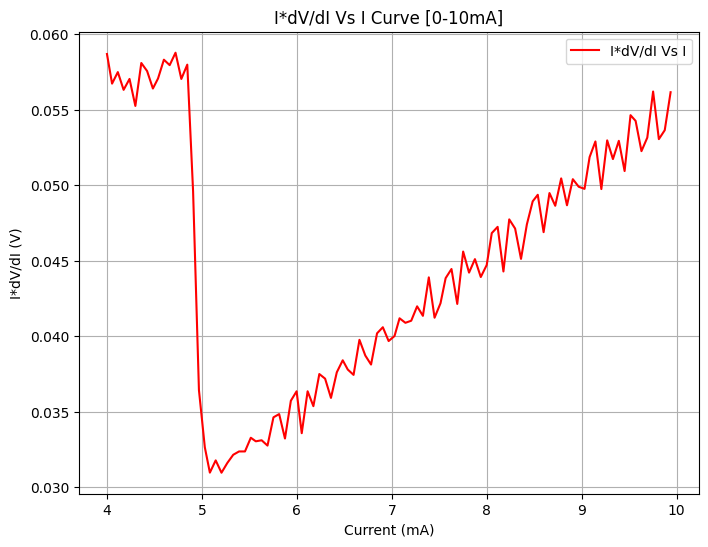

NameError: name 'voltage_at_4ith' is not defined

In [7]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.io
import matplotlib.pyplot as plt


print(os.getcwd())

LI_directory = '/Users/itaiboss/Desktop/4th_year/ELEC413/Lab/LI_Sweep'
files = os.listdir(LI_directory)
mat_files = [f for f in files if f.lower().endswith('.mat')]
print(mat_files)
# Print all file names
file_path = os.path.join(LI_directory, '2025_03_20_14_51_59_LIV_Isweep_MACOM_C10 in mW.mat')
data = scipy.io.loadmat(file_path)
isweep_struct = data['Isweep'][0]
Voltage = isweep_struct['V'][0][0]
Current = isweep_struct['I'][0][0]
Power = isweep_struct['P'][0][0]
I_set = isweep_struct['Iset'][0][0]

#Calcuate threshold current
dP = np.diff(Power)  
dI = np.diff(Current) 
dP_dI = dP / dI     

d2P=np.diff(dP)
dI2=np.diff(dI)
d2P_dI2=d2P / dI2

max_slope = np.max(dP_dI)
slope_max_index = np.argmax(np.abs(np.diff(dP_dI)))
thresh_idx=slope_max_index + 1
threshold_current = Current[thresh_idx] 

# LI PLOT
plt.figure(figsize=(8, 6))
plt.plot(Current, Power, label='Optical Power Vs Current', color='b')
plt.xlabel('Current (mA)')
plt.ylabel('Optical Power (mW)')
plt.title(f'L vs I Curve')
plt.grid(True)
plt.legend()
plt.show()

# #dL/dI Plot 
# plt.figure(figsize=(8, 6))
# plt.plot(Current[:-1], dP_dI, label='dL/dI Vs I', color='c')
# plt.xlabel('I (mA)')
# plt.ylabel('dL/dI (mW/mA)')
# plt.title(f'dL/dI Vs I Curve for {file}')
# plt.grid(True)
# plt.legend()
# plt.show()

# #d^2L/dI^2 Plot 
# plt.figure(figsize=(8, 6))
# plt.plot(Current[1:-1], d2P_dI2, label='d2L/dI2 Vs I', color='c')
# plt.xlabel('I (mA)')
# plt.ylabel('d2L/DI2 (mW^2/mA^2)')
# plt.title(f'd2L/dI2 Vs I Curve for {file}')
# plt.grid(True)
# plt.legend()
# plt.show()

#Grouped plots 
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(Current, Power, label='L vs I (Power vs Current)', color='b')
plt.xlabel('Current (mA)')
plt.ylabel('Optical Power (mW)')
plt.title(f'L-I Curve [0-10mA]')
plt.grid(True)
plt.legend()

# --- Subplot 2: dL/dI ---
plt.subplot(3, 1, 2)
plt.plot(Current[:-1], dP_dI, label='dL/dI vs I', color='orange')
plt.xlabel('Current (mA)')
plt.ylabel('dL/dI (mW/mA)')
plt.title('First Derivative of L-I Curve')
plt.grid(True)
plt.legend()

# --- Subplot 3: d²L/dI² ---
plt.subplot(3, 1, 3)
plt.plot(Current[1:-1], d2P_dI2, label='d²L/dI² vs I', color='green')
plt.xlabel('Current (mA)')
plt.ylabel('d²L/dI² (mW/mA²)')
plt.title('Second Derivative of L-I Curve')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


#V vs I Plot 
plt.figure(figsize=(8, 6))
plt.plot(Current, Voltage, label='V Vs I', color='g')
plt.xlabel('Current (mA)')
plt.ylabel('Voltage (V)')
plt.title(f'V Vs I Curve')
plt.grid(True)
plt.legend()
plt.show()



dV=np.diff(Voltage)
dV_dI = dV/dI
R_threshold = dV_dI[slope_max_index - 1]
double_threshold_current = 2 * threshold_current
double_threshold_index = np.argmin(np.abs(Current - double_threshold_current))
R_double_threshold = dV_dI[double_threshold_index - 1]
print(f"Threshold Resistance (Ith): {R_threshold} Ohm")
print(f"Threshold Resistance (2*Ith): {R_double_threshold} Ohm")



#dV vs dI Plot 
plt.figure(figsize=(8, 6))
plt.plot(Current[:-1], dV_dI, label='dV/dI Vs I', color='g')
plt.xlabel('Current (mA)')
plt.ylabel('dV/dI (V/mA)')
plt.title(f'dV/dI Vs I Curve')
plt.grid(True)
plt.legend()
plt.show()

#Grouped plots 
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(Current, Voltage, label='V Vs I', color='g')
plt.xlabel('Current (mA)')
plt.ylabel('Voltage (V)')
plt.title(f'V Vs I Curve [0-10mA]')
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(Current[:-1], dV_dI, label='dV/dI Vs I', color='g')
plt.xlabel('Current (mA)')
plt.ylabel('dV/dI (V/mA)')
plt.title(f'dV/dI Vs I Curve')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

I_dV_dI = Current[1:] * dV_dI
d_IdVdI = np.diff(I_dV_dI)
threshold_idx = np.argmax(np.abs(d_IdVdI))
threshold_current = Current[threshold_idx + 1]  # Add 1 because np.diff reduces the array size
print(f"Threshold current from d_IdVdI: {threshold_current} A")                        
#I*dV/dI vs I Plot 
plt.figure(figsize=(8, 6))
plt.plot(Current[:-1], I_dV_dI, label='I*dV/dI Vs I', color='r')
plt.xlabel('Current (mA)')
plt.ylabel('I*dV/dI (V)')
plt.title(f'I*dV/dI Vs I Curve [0-10mA]')
plt.grid(True)
plt.legend()
plt.show()


fit_current = Current[thresh_idx:]
fit_power = Power[thresh_idx:]

coeffs = np.polyfit(fit_current, fit_power, 1)
a, b = coeffs

I_4ith = 4 * threshold_current 
light_output_power = a * I_4ith + b

V_4ith = np.interp(I_4ith, Current[slope_max_index:], Voltage[slope_max_index:])

print(f"Voltage at 4*Ith: {voltage_at_4ith:.3f} V")

print(f"Power at 4*Ith: {predicted_power} mW")

print(f"Threshold current: {threshold_current} mA")
print(f"Max slope: {max_slope} mW/mA")
Ith_4 = threshold_current*4 
print(Ith_4)
# Ith_2_idx = np.argmin(np.abs(Current - Ith_2))
#Ith_4_idx = np.argmin(np.abs(Current - Ith_4))
predicted_power = V_4ith*I_4ith
print(f"Power at 4*Ith: {light_output_power} mW")
print(f"Calculated Power at 4*Ith: {predicted_power} mW")
wpe = (light_output_power/predicted_power) * 100
print(f"Wall Plug efficiency: {wpe} %") 

plt.figure(figsize=(10, 7))
plt.plot(Current, Power, label='Measured Optical Power', color='blue')

# Linear fit beyond threshold
fit_x = np.linspace(Current[0], I_4ith, 10)
fit_y = a * fit_x + b
plt.plot(fit_x, fit_y, '--', color='orange', label='Linear Fit (Above Threshold)')

# Points and annotations
plt.axvline(threshold_current, color='cyan', linestyle='--', label=f'Threshold Current: {threshold_current:.2f} mA')
plt.axvline(I_4ith, color='purple', linestyle='--', label=f'4×Ith: {I_4ith:.2f} mA')

plt.plot(I_4ith, light_output_power, 'bo', label=f'Predicted Optical Power at 4×Ith = {light_output_power:.4f}')
#plt.plot(I_4ith, predicted_power, 'ko', label='Electrical Power at 4×Ith')

# Labels and title
plt.xlabel('Current (mA)')
plt.ylabel('Power (mW)')
plt.title(f'Optical and Electrical Power at 4×Ith')
plt.grid(True)
plt.legend()
plt.show()
    
    
    

['OSA_Tsweep_DFBLaser_C10_I=17_2025_03_20_15_19_59OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=4.75_2025_03_20_15_12_55OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=25_2025_03_20_15_00_16OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=5.25_2025_03_20_15_13_47OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=18_2025_03_20_15_20_16OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=15_2025_03_20_14_59_41OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=4.9_2025_03_20_15_13_12OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=0_2025_03_20_14_58_49OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=19_2025_03_20_15_20_33OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=16_2025_03_20_15_19_41OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=4.5_2025_03_20_15_12_37OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=5_2025_03_20_15_13_30OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=10_2025_03_20_14_59_23OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=20_2025_03_20_14_59_58OSA_Sweep.mat']
3 dB Bandwidth at I=25 mA: 0.0601 nm
3 dB Bandwidth at I=15 mA: 0.0608 nm
3 dB Bandwi

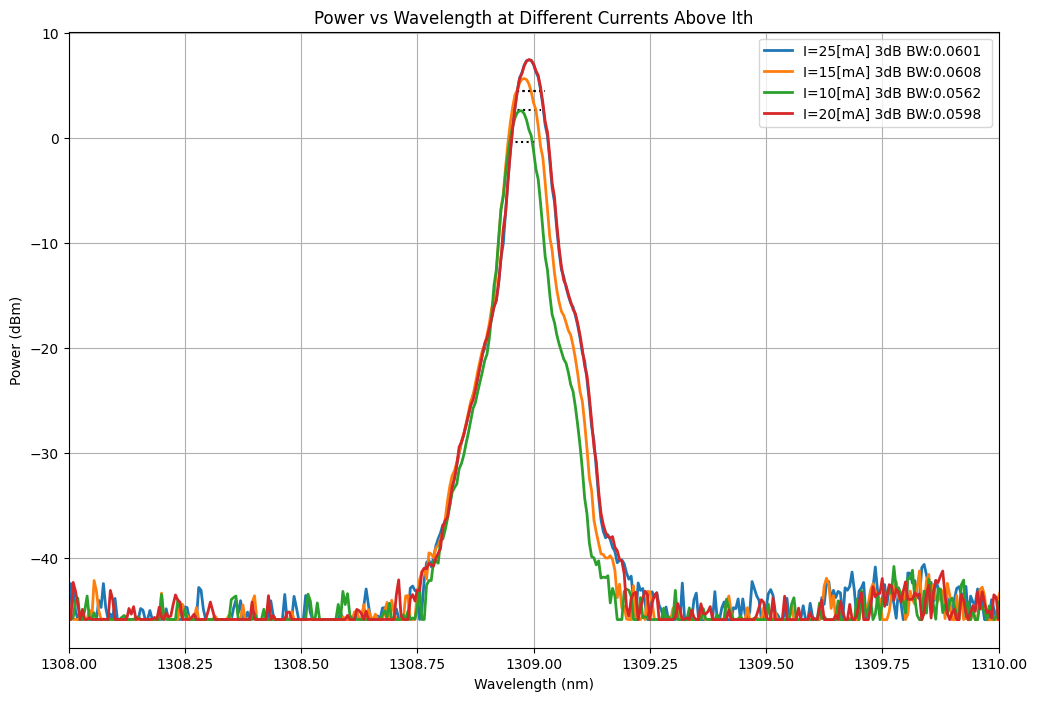

[1308.97 1308.98 1308.99 1308.99]
Tuning coefficient: 0.0014 nm/mA


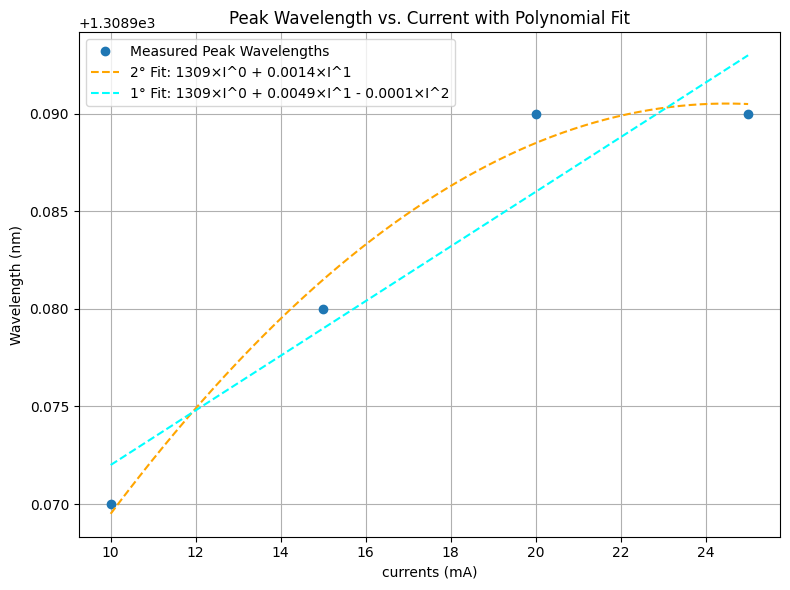

In [25]:
import re
OSI_directory = '/Users/itaiboss/Desktop/4th_year/ELEC413/Lab/Optical_spectrum/I_var'
files = os.listdir(OSI_directory)
mat_files = [f for f in files if f.lower().endswith('.mat')]
print(mat_files)
# Print all file names

plt.figure(figsize=(12, 8))

peak_wavelengths = []
currents = []

for file in mat_files:
    file_path = os.path.join(OSI_directory, file)
    match = re.search(r'I=([\d.]+)', file_path)
    if (float(match.group(1))%5 ==0 and float(match.group(1))>5):
        data = scipy.io.loadmat(file_path)
        Power = data["Power"][0]
        Wavelength = data["Wavelength"][0]*1e9

        #calculate - 3db BW
        peak_power = np.max(Power)
        target_power = peak_power - 3

        peak_idx = np.argmax(Power)

        #For peak fitting
        peak_wavelengths.append(Wavelength[peak_idx])
        currents.append(int(match.group(1)))
        
        left_idx = np.where(Power[:peak_idx] <= target_power)[0]
        if left_idx.size > 0:
            left_cross = np.interp(target_power,
                                   [Power[left_idx[-1]], Power[left_idx[-1]+1]],
                                   [Wavelength[left_idx[-1]], Wavelength[left_idx[-1]+1]])
        else:
            left_cross = Wavelength[0]

        right_idx = np.where(Power[peak_idx:] <= target_power)[0]
        if right_idx.size > 0 and (peak_idx + right_idx[0] + 1) < len(Wavelength):
            idx1 = peak_idx + right_idx[0]
            right_cross = np.interp(target_power,
                                    [Power[idx1], Power[idx1+1]],
                                    [Wavelength[idx1], Wavelength[idx1+1]])
        else:
            right_cross = Wavelength[-1]

        bandwidth = (right_cross - left_cross)  # convert to nm
        print(f"3 dB Bandwidth at I={match.group(1)} mA: {bandwidth:.4f} nm")
        plt.hlines(target_power, left_cross, right_cross, colors='k', linestyles='dotted')
        plt.plot(Wavelength, Power, label=f'I={match.group(1)}[mA] 3dB BW:{bandwidth:.4f} ', linewidth=2)


        
plt.xlabel('Wavelength (nm)') 
plt.ylabel('Power (dBm)') 
plt.xlim(1308, 1310)
plt.title('Power vs Wavelength at Different Currents Above Ith')
plt.grid(True)
plt.legend()
plt.show()


currents = np.array(currents)
currents = np.sort(currents)
smooth_temps = np.linspace(currents.min(), currents.max(), 300)
peak_wavelengths = np.sort(peak_wavelengths)
print(peak_wavelengths)
coeffs = np.polyfit(currents, peak_wavelengths, 1)
coeffs2 = np.polyfit(currents, peak_wavelengths, 2)

fit_func2 = np.poly1d(coeffs2)
fit_func = np.poly1d(coeffs)


smooth_fit2 = fit_func2(smooth_temps)
smooth_fit = fit_func(smooth_temps)
tuning_coeff= coeffs[0]
print(f"Tuning coefficient: {tuning_coeff:.4f} nm/mA")

eq_terms = [f"{coeff:.4g}×I^{i}" for i, coeff in enumerate(reversed(coeffs))]
fit_eq = " + ".join(eq_terms).replace("+ -", "- ")

eq_terms = [f"{coeff:.4g}×I^{i}" for i, coeff in enumerate(reversed(coeffs2))]
fit_eq2 = " + ".join(eq_terms).replace("+ -", "- ")

plt.figure(figsize=(8, 6))
plt.plot(currents, peak_wavelengths, 'o', label='Measured Peak Wavelengths')
plt.plot(smooth_temps, smooth_fit2, '--', color='orange', label=f'{2}° Fit: {fit_eq}')
plt.plot(smooth_temps, smooth_fit, '--', color='cyan', label=f'{1}° Fit: {fit_eq2}')

plt.xlabel('currents (mA)')
plt.ylabel('Wavelength (nm)')
plt.title('Peak Wavelength vs. Current with Polynomial Fit')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()







['OSA_Tsweep_DFBLaser_C10_I=17_2025_03_20_15_19_59OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=4.75_2025_03_20_15_12_55OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=25_2025_03_20_15_00_16OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=5.25_2025_03_20_15_13_47OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=18_2025_03_20_15_20_16OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=15_2025_03_20_14_59_41OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=4.9_2025_03_20_15_13_12OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=0_2025_03_20_14_58_49OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=19_2025_03_20_15_20_33OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=16_2025_03_20_15_19_41OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=4.5_2025_03_20_15_12_37OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=5_2025_03_20_15_13_30OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=10_2025_03_20_14_59_23OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_I=20_2025_03_20_14_59_58OSA_Sweep.mat']
3 dB Bandwidth at I=4.75 mA: 0.0735 nm
3 dB Bandwidth at I=5.25 mA: 0.0583 nm
3 dB Ba

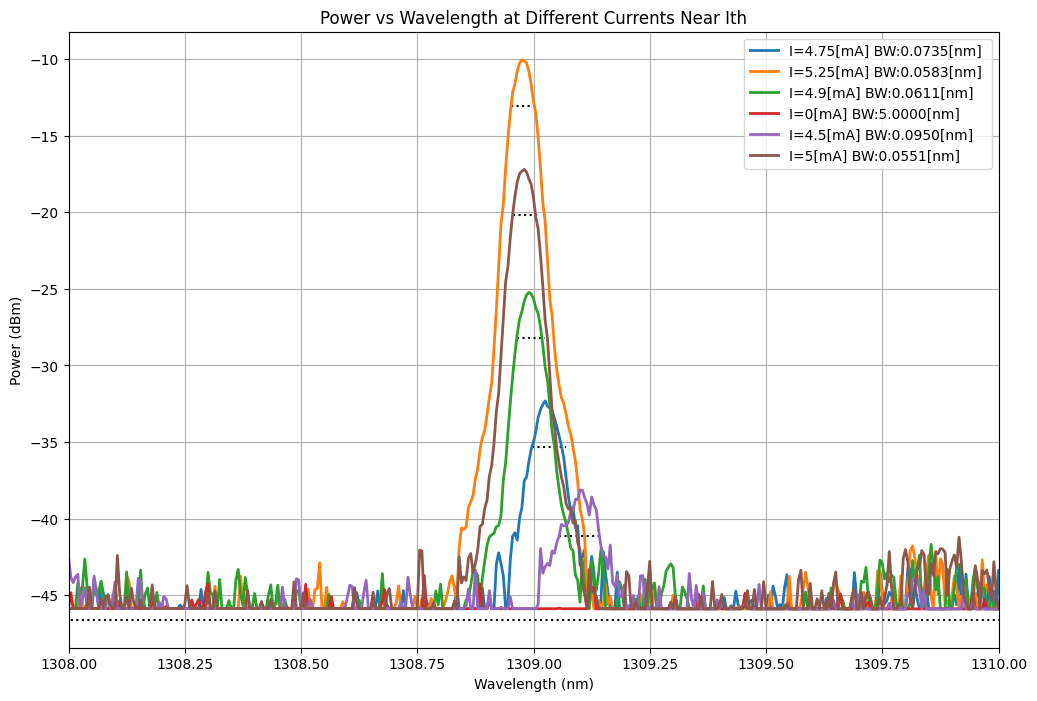

In [12]:
OSI_directory = '/Users/itaiboss/Desktop/4th_year/ELEC413/Lab/Optical_spectrum/I_var'
files = os.listdir(OSI_directory)
mat_files = [f for f in files if f.lower().endswith('.mat')]
print(mat_files)
# Print all file names

plt.figure(figsize=(12, 8))

for file in mat_files:
    file_path = os.path.join(OSI_directory, file)
    match = re.search(r'I=([\d.]+)', file_path)
    if (float(match.group(1))<6):
        data = scipy.io.loadmat(file_path)
        Power = data["Power"][0]
        Wavelength = data["Wavelength"][0]*1e9

        #calculate - 3db BW
        peak_power = np.max(Power)
        target_power = peak_power - 3

        peak_idx = np.argmax(Power)

        left_idx = np.where(Power[:peak_idx] <= target_power)[0]
        if left_idx.size > 0:
            left_cross = np.interp(target_power,
                                   [Power[left_idx[-1]], Power[left_idx[-1]+1]],
                                   [Wavelength[left_idx[-1]], Wavelength[left_idx[-1]+1]])
        else:
            left_cross = Wavelength[0]

        right_idx = np.where(Power[peak_idx:] <= target_power)[0]
        if right_idx.size > 0 and (peak_idx + right_idx[0] + 1) < len(Wavelength):
            idx1 = peak_idx + right_idx[0]
            right_cross = np.interp(target_power,
                                    [Power[idx1], Power[idx1+1]],
                                    [Wavelength[idx1], Wavelength[idx1+1]])
        else:
            right_cross = Wavelength[-1]

        bandwidth = (right_cross - left_cross)  # convert to nm
        print(f"3 dB Bandwidth at I={match.group(1)} mA: {bandwidth:.4f} nm")
        plt.hlines(target_power, left_cross, right_cross, colors='k', linestyles='dotted')
        plt.plot(Wavelength, Power, label=f'I={match.group(1)}[mA] BW:{bandwidth:.4f}[nm] ', linewidth=2)

        
        
plt.xlabel('Wavelength (nm)')  # Adjust the unit to match your data
plt.ylabel('Power (dBm)')  # Adjust the unit to match your data
plt.xlim(1308, 1310)
plt.title('Power vs Wavelength at Different Currents Near Ith')
plt.grid(True)
plt.legend()  # Add a legend to differentiate the files

# Show the plot
plt.show()

['OSA_Tsweep_DFBLaser_C10_T=15_2025_03_20_15_09_27OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_T=35_2025_03_20_15_10_10OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_T=30_2025_03_20_15_05_48OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_T=20_2025_03_20_15_04_23OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_T=40_2025_03_20_15_10_52OSA_Sweep.mat', 'OSA_Tsweep_DFBLaser_C10_T=25_2025_03_20_15_05_05OSA_Sweep.mat']
3 dB Bandwidth at I=15 mA: 0.0571 nm
3 dB Bandwidth at I=35 mA: 0.0585 nm
3 dB Bandwidth at I=30 mA: 0.0582 nm
3 dB Bandwidth at I=20 mA: 0.0590 nm
3 dB Bandwidth at I=40 mA: 0.0581 nm
3 dB Bandwidth at I=25 mA: 0.0575 nm


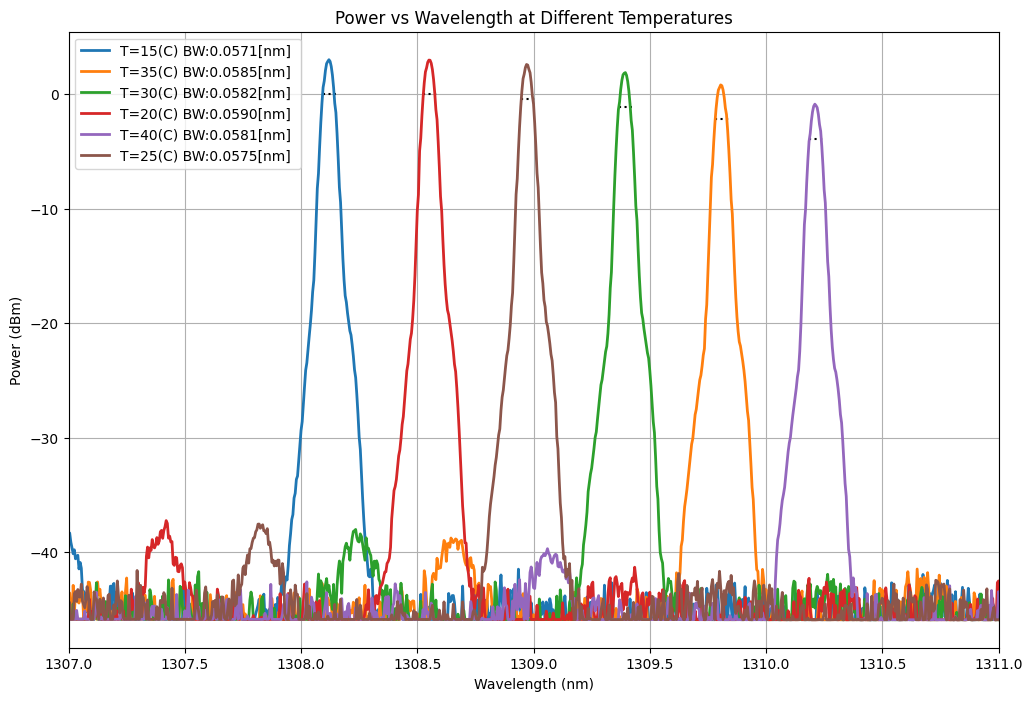

[1308.12  1308.55  1308.97  1309.395 1309.805 1310.21 ]
Tuning coefficient: 0.0837 nm/mA


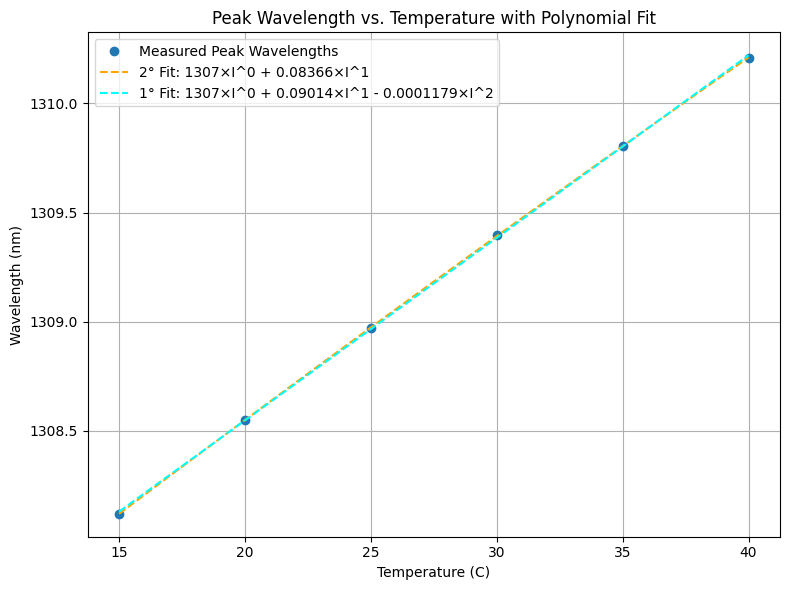

In [13]:
OST_directory = '/Users/itaiboss/Desktop/4th_year/ELEC413/Lab/Optical_spectrum/T_var'
files = os.listdir(OST_directory)
mat_files = [f for f in files if f.lower().endswith('.mat')]
print(mat_files)
# Print all file names

plt.figure(figsize=(12, 8))

peak_wavelengths = []
temps = []

for file in mat_files:
    file_path = os.path.join(OST_directory, file)
    match = re.search(r'T=([\d.]+)', file_path)
    data = scipy.io.loadmat(file_path)
    Power = data["Power"][0]
    Wavelength = data["Wavelength"][0]*1e9

    #calculate - 3db BW
    peak_power = np.max(Power)
    target_power = peak_power - 3

    peak_idx = np.argmax(Power)

    peak_wavelengths.append(Wavelength[peak_idx])
    temps.append(int(match.group(1)))

    left_idx = np.where(Power[:peak_idx] <= target_power)[0]
    if left_idx.size > 0:
        left_cross = np.interp(target_power,
                               [Power[left_idx[-1]], Power[left_idx[-1]+1]],
                               [Wavelength[left_idx[-1]], Wavelength[left_idx[-1]+1]])
    else:
        left_cross = Wavelength[0]

    right_idx = np.where(Power[peak_idx:] <= target_power)[0]
    if right_idx.size > 0 and (peak_idx + right_idx[0] + 1) < len(Wavelength):
        idx1 = peak_idx + right_idx[0]
        right_cross = np.interp(target_power,
                                [Power[idx1], Power[idx1+1]],
                                [Wavelength[idx1], Wavelength[idx1+1]])
    else:
        right_cross = Wavelength[-1]

    bandwidth = (right_cross - left_cross)  # convert to nm
    print(f"3 dB Bandwidth at I={match.group(1)} mA: {bandwidth:.4f} nm")
    plt.hlines(target_power, left_cross, right_cross, colors='k', linestyles='dotted')
    plt.plot(Wavelength, Power, label=f'T={match.group(1)}(C) BW:{bandwidth:.4f}[nm] ', linewidth=2)
    
plt.xlabel('Wavelength (nm)')  
plt.ylabel('Power (dBm)')  
plt.xlim(1307, 1311)
plt.title('Power vs Wavelength at Different Temperatures')
plt.grid(True)
plt.legend() 

# Show the plot
plt.show()


temps = np.array(temps)
temps = np.sort(temps)
smooth_temps = np.linspace(temps.min(), temps.max(), 300)
peak_wavelengths = np.sort(peak_wavelengths)
print(peak_wavelengths)
coeffs = np.polyfit(temps, peak_wavelengths, 1)
coeffs2 = np.polyfit(temps, peak_wavelengths, 2)

fit_func2 = np.poly1d(coeffs2)
fit_func = np.poly1d(coeffs)


smooth_fit2 = fit_func2(smooth_temps)
smooth_fit = fit_func(smooth_temps)
tuning_coeff= coeffs[0]
print(f"Tuning coefficient: {tuning_coeff:.4f} nm/mA")

eq_terms = [f"{coeff:.4g}×I^{i}" for i, coeff in enumerate(reversed(coeffs))]
fit_eq = " + ".join(eq_terms).replace("+ -", "- ")

eq_terms = [f"{coeff:.4g}×I^{i}" for i, coeff in enumerate(reversed(coeffs2))]
fit_eq2 = " + ".join(eq_terms).replace("+ -", "- ")

plt.figure(figsize=(8, 6))
plt.plot(temps, peak_wavelengths, 'o', label='Measured Peak Wavelengths')
plt.plot(smooth_temps, smooth_fit2, '--', color='orange', label=f'{2}° Fit: {fit_eq}')
plt.plot(smooth_temps, smooth_fit, '--', color='cyan', label=f'{1}° Fit: {fit_eq2}')

plt.xlabel('Temperature (C)')
plt.ylabel('Wavelength (nm)')
plt.title('Peak Wavelength vs. Temperature with Polynomial Fit')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
